In [45]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

In [46]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2025-10-11 10:20:42--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv.1’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.05s   

2025-10-11 10:20:42 (18.0 MB/s) - ‘car_fuel_efficiency.csv.1’ saved [874188/874188]



In [47]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [48]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


#Целью данного домашнего задания является создание регрессионной модели для прогнозирования топливной экономичности автомобиля (столбец 'fuel_efficiency_mpg').

Используйте только следующие столбцы:

* 'engine_displacement',
* 'horsepower',
* 'vehicle_weight',
* 'model_year',
* 'fuel_efficiency_mpg'


ЕДА
* Посмотрите на fuel_efficiency_mpg переменную. У неё длинный хвост?

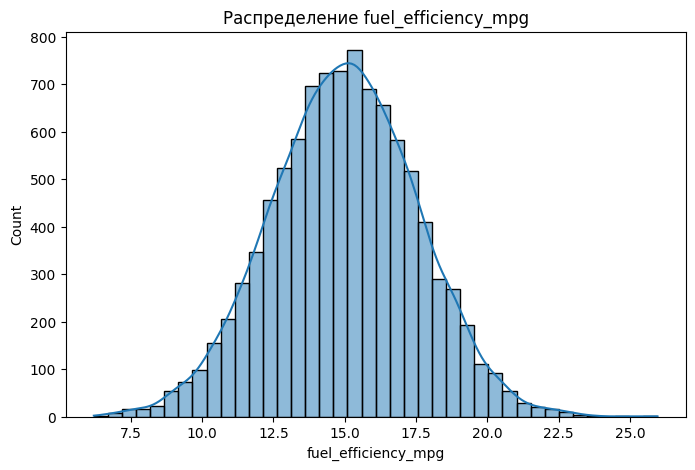

In [50]:
plt.figure(figsize=(8, 5))
sns.histplot(df.fuel_efficiency_mpg, kde=True, bins=40)
plt.title('Распределение fuel_efficiency_mpg')
plt.show()

In [51]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head(10)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
5,190,NaN,2484.883986,2008,17.271818
6,240,127.0,3006.542287,2012,13.210412
7,150,239.0,3638.657780,2020,12.848884
8,250,174.0,2714.219310,2016,16.823554
9,150,123.0,3509.036569,2005,12.298355


In [52]:
df.isnull().sum()

,0
engine_displacement,0
horsepower,708
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [53]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,9704.000000,8996.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,149.657292,3001.280993,2011.484027,14.985243
std,49.455319,29.879555,497.894860,6.659808,2.556468
min,10.000000,37.000000,952.681761,2000.000000,6.200971
25%,170.000000,130.000000,2666.248985,2006.000000,13.267459
50%,200.000000,149.000000,2993.226296,2012.000000,15.006037
75%,230.000000,170.000000,3334.957039,2017.000000,16.707965
max,380.000000,271.000000,4739.077089,2023.000000,25.967222


#Подготовить и разделить набор данных
Перемешайте набор данных (отфильтрованный, который вы создали выше), используйте seed 42.
Разделите данные на обучающие/валидационные/тестовые наборы с распределением 60%/20%/20%.

In [54]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

print(f'n_val: {n_val}, n_test: {n_test}, n_train: {n_train}, n: {n}')
assert(n_val + n_test + n_train == n)

n_val: 1940, n_test: 1940, n_train: 5824, n: 9704


In [55]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)
idx

array([ 483, 7506, 8795, ..., 5390,  860, 7270])

In [56]:
df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [57]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209
...,...,...,...,...,...
1696,260,139.0,2606.972984,2009,16.964054
5685,280,132.0,4004.214323,2014,10.059094
6735,210,152.0,2500.175687,2020,17.593237
2052,250,154.0,2254.313245,2002,18.925748


In [58]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [59]:
df_train = df_train.reset_index(drop=True)
df_test = df_train.reset_index(drop=True)
df_val = df_train.reset_index(drop=True)

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

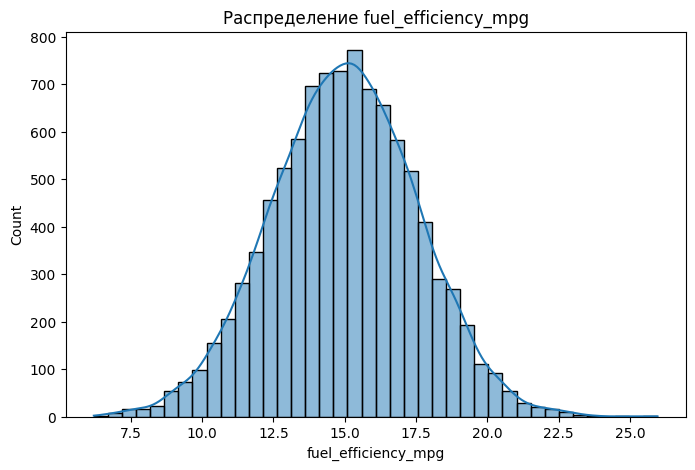

In [60]:
plt.figure(figsize=(8, 5))
sns.histplot(df.fuel_efficiency_mpg, kde=True, bins=40)
plt.title('Распределение fuel_efficiency_mpg')
plt.show()

#Нам необходимо разобраться с пропущенными значениями в столбце из Q1.
* У нас есть два варианта: заполнить его 0 или средним значением этой переменной.
* Попробуйте оба варианта. Для каждого из них обучите модель линейной регрессии без регуляризации, используя код из уроков.
* Для вычисления среднего значения используйте только обучающую выборку!
* Используйте проверочный набор данных для оценки моделей и сравнения среднеквадратичного отклонения каждого варианта.
* Округлите оценки RMSE до 2 десятичных знаков, используяround(score, 2)

In [61]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight']
df_num = df_train[base]
df_num.isnull().sum()

,0
engine_displacement,0
horsepower,429
vehicle_weight,0


In [62]:
df_num_fillna_0 = df_num.fillna(0)
df_num_fillna_mean = df_num.fillna(df['horsepower'].mean())

In [63]:
X_train_0 = df_num_fillna_0.values
y_train_mean = df_num_fillna_mean.values

In [64]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [65]:
w0, w = train_linear_regression(X_train_0, y_train)
_w0, _w = train_linear_regression(y_train_mean, y_train)

In [66]:
y_pred_0 = w0 + X_train_0.dot(w)
y_pred_mean = _w0 + y_train_mean.dot(_w)

<Axes: ylabel='Count'>

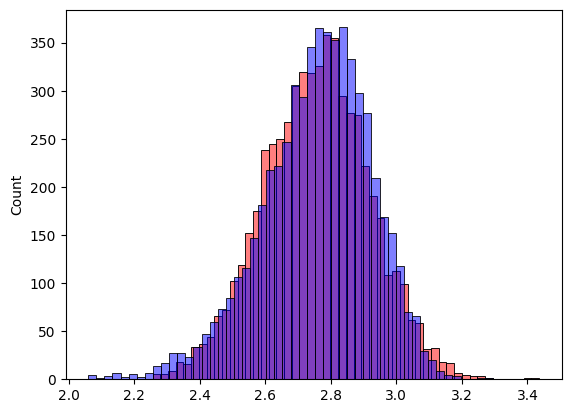

In [67]:
sns.histplot(y_pred_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

<Axes: ylabel='Count'>

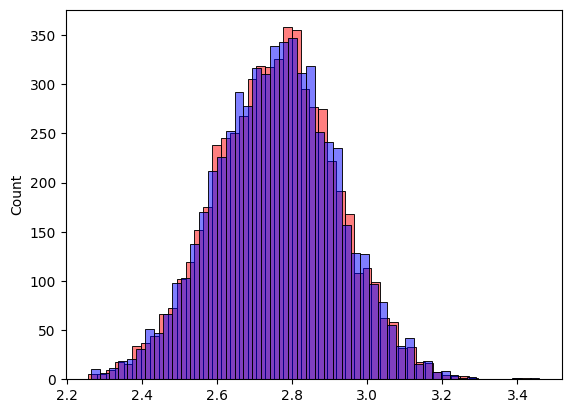

In [68]:
sns.histplot(y_pred_0, color='red', alpha=0.5, bins=50)
sns.histplot(y_pred_mean, color='blue', alpha=0.5, bins=50)

In [69]:
def rmse(y, y_pred):
  se = (y - y_pred) ** 2
  mse = se.mean()
  return np.sqrt(mse)

In [70]:
score1 = rmse(y_train, y_pred_0)
score2 = rmse(y_train, y_pred_mean)

In [71]:
print(round(score1, 5))
print(round(score2, 5))

0.03909
0.03581


In [72]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [73]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year
0,220,144.0,2535.887591,2009
1,160,141.0,2741.170484,2019
2,230,155.0,2471.880237,2017
3,150,206.0,3748.164469,2015
4,300,111.0,2135.716359,2006


In [74]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 8)

np.float64(0.03908648)

In [75]:
X_train

array([[ 220.        ,  144.        , 2535.88759124],
       [ 160.        ,  141.        , 2741.17048439],
       [ 230.        ,  155.        , 2471.88023726],
       ...,
       [ 210.        ,  152.        , 2500.17568746],
       [ 250.        ,  154.        , 2254.31324473],
       [ 210.        ,  152.        , 2435.20360628]])

In [76]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2023 - df.model_year
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [77]:
X_train = prepare_X(df_train)

In [78]:
X_train

array([[ 220.        ,  144.        , 2535.88759124,   14.        ],
       [ 160.        ,  141.        , 2741.17048439,    4.        ],
       [ 230.        ,  155.        , 2471.88023726,    6.        ],
       ...,
       [ 210.        ,  152.        , 2500.17568746,    3.        ],
       [ 250.        ,  154.        , 2254.31324473,   21.        ],
       [ 210.        ,  152.        , 2435.20360628,   19.        ]])

In [79]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

round(rmse(y_val, y_pred), 8)

np.float64(0.03908633)

#Теперь давайте обучим регуляризованную линейную регрессию.
* В этом вопросе заполните поле «NA» цифрой 0.
* Попробуйте другие значения rиз этого списка: [0, 0.01, 0.1, 1, 5, 10, 100].
* Используйте RMSE для оценки модели на проверочном наборе данных.
* Округлите значения RMSE до двух десятичных знаков.

In [80]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [81]:
X_train = prepare_X(df_train)

In [82]:
for r in [0, 0.001, 0.01, 0.1, 1, 10]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    print('%5s, %.8f' % (r, round(rmse(y_val, y_pred), 8)))

    0, 0.03908633
0.001, 0.03908635
 0.01, 0.03908853
  0.1, 0.03930551
    1, 0.05667078
   10, 0.37486894


# Для разделения данных мы использовали начальное число 42. Давайте выясним, как выбор начального числа влияет на наш результат.
* Попробуйте другие начальные значения: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
* Для каждого начального набора выполните разделение на обучение/проверку/тест с распределением 60%/20%/20%.
* Заполните пропущенные значения нулями и обучите модель без регуляризации.
* Для каждого семени оцените модель на проверочном наборе данных и соберите оценки RMSE.
* Каково стандартное отклонение всех оценок? Чтобы вычислить стандартное отклонение, используйте np.std.
* Округлите результат до 3 десятичных знаков ( round(std, 3))

In [83]:
def prepare_X(df, base):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

def func(seed):
    idx = np.arange(len(df))
    np.random.seed(seed)
    np.random.shuffle(idx)

    # Разделение данных
    df_shuffled = df.iloc[idx]
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
    df_test = df_shuffled.iloc[n_train + n_val:].copy()

    # Подготовка целевой переменной
    y_train = np.log1p(df_train['fuel_efficiency_mpg'].values)
    y_val = np.log1p(df_val['fuel_efficiency_mpg'].values)
    y_test = np.log1p(df_test['fuel_efficiency_mpg'].values)

    # Удаление целевой переменной
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Подготовка данных
    X_train = prepare_X(df_train, base)
    X_val = prepare_X(df_val, base)

    # Обучение модели
    w0, w = train_linear_regression(X_train, y_train)

    # Предсказание на валидационной выборке
    y_pred = w0 + X_val.dot(w)

    return rmse(y_val, y_pred)

In [84]:
array = []
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for seed in seeds:
  array.append(func(seed))

round(np.std(array), 3)

np.float64(0.001)

In [85]:
def func(seed):
    idx = np.arange(len(df))
    np.random.seed(seed)
    np.random.shuffle(idx)

    # Разделение данных
    df_shuffled = df.iloc[idx]
    df_train = df_shuffled.iloc[:n_train].copy()
    df_val = df_shuffled.iloc[n_train:n_train + n_val].copy()
    df_test = df_shuffled.iloc[n_train + n_val:].copy()
    df_train_val = pd.concat([df_train, df_val])

    # Подготовка целевой переменной
    y_train = np.log1p(df_train['fuel_efficiency_mpg'].values)
    y_val = np.log1p(df_val['fuel_efficiency_mpg'].values)
    y_test = np.log1p(df_test['fuel_efficiency_mpg'].values)
    y_train_val = np.log1p(df_train_val['fuel_efficiency_mpg'].values)

    # Удаление целевой переменной
    del df_train_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    # Подготовка данных
    X_train_val = prepare_X(df_train_val, base)
    X_test = prepare_X(df_test, base)

    # Обучение модели с регуляризацией r=0.001
    w0, w = train_linear_regression_reg(X_train_val, y_train_val, r=0.001)

    # Предсказание на тестовой выборке
    y_pred = w0 + X_test.dot(w)

    return rmse(y_test, y_pred)

In [86]:
round(func(9), 3)

np.float64(0.039)